In [3]:
# CELL 1 — Install dependencies (CNN-LSTM only)
# ============================================================
import subprocess
subprocess.run(["pip", "install", "-q", "imbalanced-learn"], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LSTM,
    Conv1D, MaxPooling1D,
    BatchNormalization, Concatenate
)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

from scipy import stats
from scipy.stats import entropy

print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ GPU: {tf.config.list_physical_devices('GPU')}")
print("✅ All libraries loaded!")

✅ TensorFlow: 2.20.0
✅ GPU: []
✅ All libraries loaded!


In [4]:
# CELL 2 — Load Dataset
# ============================================================
import os

DATASET_FILENAME = "Book4-7-4months.csv"

def load_dataset():
    direct_path = f"/content/{DATASET_FILENAME}"

    if os.path.exists(direct_path):
        print(f"📂 Found dataset at: {direct_path}")

        # ── اقرأ الملف كامل عشان نشوف شكله الأول ────────────
        df_raw = pd.read_csv(direct_path, header=None)
        print(f"\n🔍 أول 3 صفوف خام:")
        print(df_raw.head(3))

        # ── شوف انهي صف فيه التواريخ ─────────────────────────
        # الصف اللي فيه تواريخ هو الـ header الحقيقي
        header_row = None
        for i in range(min(5, len(df_raw))):
            row_vals = df_raw.iloc[i].astype(str).tolist()
            # لو فيه قيمة تشبه تاريخ → ده الـ header
            if any('/' in v or '-' in v or '201' in v for v in row_vals):
                header_row = i
                print(f"\n✅ التواريخ موجودة في الصف رقم: {header_row}")
                break

        if header_row is None:
            print("⚠️ مش لاقي تواريخ — هستخدم الصف الأول كـ header")
            header_row = 0

        df = pd.read_csv(direct_path, header=header_row)
        return df

    # ── لو مش موجود → رفع يدوي ───────────────────────────────
    print(f"⬆️  Please upload '{DATASET_FILENAME}' now:")
    from google.colab import files
    uploaded = files.upload()

    if DATASET_FILENAME not in uploaded:
        raise FileNotFoundError(
            f"❌ الملف المرفوع مش اسمه '{DATASET_FILENAME}'!\n"
            f"   الملفات اللي اترفعت: {list(uploaded.keys())}"
        )

    df_raw = pd.read_csv(DATASET_FILENAME, header=None)
    header_row = None
    for i in range(min(5, len(df_raw))):
        row_vals = df_raw.iloc[i].astype(str).tolist()
        if any('/' in v or '-' in v or '201' in v for v in row_vals):
            header_row = i
            break
    if header_row is None:
        header_row = 0

    df = pd.read_csv(DATASET_FILENAME, header=header_row)
    return df


df = load_dataset()

print(f"\n✅ Dataset shape: {df.shape}")
print(f"📊 Columns (first 10): {df.columns.tolist()[:10]}")
print(f"📊 Columns (last  5) : {df.columns.tolist()[-5:]}")
print(f"📊 dtypes:\n{df.dtypes.value_counts()}")

# ── معلومات الداتا ────────────────────────────────────────────
numeric_cols_count = df.select_dtypes(include=[np.number, 'float64']).shape[1]
print(f"\n⏱️  Timesteps المتاحة  : {numeric_cols_count}")
print(f"   = {numeric_cols_count} يوم")
print(f"   = {numeric_cols_count/7:.1f} أسبوع")
print(f"   = {numeric_cols_count/30:.1f} شهر")
print(f"   = 4 شهور تقريباً ({numeric_cols_count} يوم)")

df.head(3)

📂 Found dataset at: /content/Book4-7-4months.csv

🔍 أول 3 صفوف خام:
          0           1           2           3           4           5    \
0  01/01/2014  01/02/2014  01/03/2014  01/04/2014  01/05/2014  01/06/2014   
1        0.03        0.03        0.03        0.02        0.03        0.03   
2        0.03        0.01        0.05        0.21        0.15        0.17   

          6           7           8           9    ...        112        113  \
0  01/07/2014  01/08/2014  01/09/2014  01/10/2014  ...  4/23/2014  4/24/2014   
1        0.03        0.02        0.04        0.03  ...        NaN          0   
2        0.04        0.12        0.06        0.18  ...        0.7       0.88   

         114        115        116        117        118        119  \
0  4/25/2014  4/26/2014  4/27/2014  4/28/2014  4/29/2014  4/30/2014   
1       0.14       0.04       0.06       0.05       0.06       0.07   
2       0.01       0.01       0.05       0.01       0.03       0.49   

                 

,01/01/2014,01/02/2014,01/03/2014,01/04/2014,01/05/2014,01/06/2014,01/07/2014,01/08/2014,01/09/2014,01/10/2014,...,4/23/2014,4/24/2014,4/25/2014,4/26/2014,4/27/2014,4/28/2014,4/29/2014,4/30/2014,CONS_NO,FLAG
0,0.03,0.03,0.03,0.02,0.03,0.03,0.03,0.02,0.04,0.03,...,NaN,0.00,0.14,0.04,0.06,0.05,0.06,0.07,1CE42DCD5B59DE4FF826612A17BA85A5,0.0
1,0.03,0.01,0.05,0.21,0.15,0.17,0.04,0.12,0.06,0.18,...,0.70,0.88,0.01,0.01,0.05,0.01,0.03,0.49,A36AC19E74E851D7363DD7D37202BB7A,0.0
2,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,...,6.37,6.04,7.05,8.36,10.13,8.89,7.96,8.14,B7A54A2564FCD6844C50AC4BB8D61523,0.0


In [5]:
# CELL 3 — Data Preparation & Label Extraction
# ============================================================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# ── استخراج X و y ──────────────────────────────────────────
if 'FLAG' in df.columns:
    y_raw = df['FLAG'].values.astype(int)
    X_raw = df.drop(columns=['FLAG']).select_dtypes(include=[np.number]).values.astype(float)
elif 'label' in df.columns:
    y_raw = df['label'].values.astype(int)
    X_raw = df.drop(columns=['label']).select_dtypes(include=[np.number]).values.astype(float)
elif 'Label' in df.columns:
    y_raw = df['Label'].values.astype(int)
    X_raw = df.drop(columns=['Label']).select_dtypes(include=[np.number]).values.astype(float)
else:
    # افتراضياً: آخر عمود رقمي هو الـ Label
    print(f"⚠️  لم يُوجد عمود FLAG/label — سيُستخدم آخر عمود: '{numeric_cols[-1]}'")
    y_raw = df[numeric_cols[-1]].values.astype(int)
    X_raw = df[numeric_cols[:-1]].values.astype(float)

# ── تنظيف ──────────────────────────────────────────────────
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

# ── تطبيع الـ Labels → 0 و 1 فقط ──────────────────────────
unique_labels = np.unique(y_raw)
print(f"Unique labels: {unique_labels}")

if set(unique_labels) == {0, 1}:
    y = y_raw.copy()
else:
    y = (y_raw > 0).astype(int)
    print(f"⚠️  Labels تم تحويلها → 0/1")

# ── التحقق من صحة البيانات ─────────────────────────────────
if X_raw.shape[0] == 0:
    raise ValueError("❌ X_raw فارغ! تحقق من الداتاسيت")
if X_raw.shape[1] < 10:
    raise ValueError(f"❌ عدد الـ timesteps ({X_raw.shape[1]}) صغير جداً!")

# ── إحصائيات ───────────────────────────────────────────────
print(f"\n📊 Dataset Statistics:")
print(f"   Total samples     : {len(y):,}")
print(f"   Benign  (0)       : {np.sum(y==0):,} ({np.sum(y==0)/len(y)*100:.1f}%)")
print(f"   Theft   (1)       : {np.sum(y==1):,} ({np.sum(y==1)/len(y)*100:.1f}%)")
print(f"   Time-series length: {X_raw.shape[1]} timesteps")
print(f"   Class imbalance   : 1:{np.sum(y==0)//max(np.sum(y==1),1)}")

Unique labels: [-9223372036854775808                    0                    1]
⚠️  Labels تم تحويلها → 0/1

📊 Dataset Statistics:
   Total samples     : 18,194
   Benign  (0)       : 16,599 (91.2%)
   Theft   (1)       : 1,595 (8.8%)
   Time-series length: 120 timesteps
   Class imbalance   : 1:10


In [6]:
# CELL 4 — 12 Data Manipulation Techniques
# ============================================================
def apply_manipulation_techniques(X_benign, seed=42):
    np.random.seed(seed)
    n, T = X_benign.shape
    manipulated = []

    for i, E in enumerate(X_benign):
        mean_E = np.mean(E)

        # MT-1: Multiply by fixed β
        beta = np.random.uniform(0.1, 0.9)
        manipulated.append(E * beta)

        # MT-2: Multiply by continuous β series
        beta_con = np.random.uniform(0.1, 0.9, size=T)
        manipulated.append(E * beta_con)

        # MT-3: Random binary mask
        rand_01 = np.random.choice([0, 1], size=T, p=[0.3, 0.7])
        manipulated.append(E * rand_01)

        # MT-4: mean × random scalar
        r4 = np.random.uniform(0.1, 1.0)
        manipulated.append(np.full(T, mean_E * r4))

        # MT-5: Constant mean replacement
        manipulated.append(np.full(T, mean_E))

        # MT-6: Time reversal
        manipulated.append(E[::-1].copy())

        # MT-7: Inverse reporting
        r7 = np.random.uniform(0.1, 0.9)
        E_div = np.clip(E, 1.0 + 1e-9, mean_E + 1e-9)
        manipulated.append((mean_E * r7) / E_div)

        # MT-8: sqrt(mean × β) constant
        r8 = np.random.uniform(0.1, 0.9)
        manipulated.append(np.full(T, np.sqrt(max(mean_E * r8, 0))))

        # MT-9: sqrt(E × β) element-wise
        r9 = np.random.uniform(0.1, 0.9)
        manipulated.append(np.sqrt(np.abs(E * r9)))

        # MT-10: mean − gamma constant
        gamma10 = np.random.uniform(0, mean_E)
        manipulated.append(np.full(T, max(mean_E - gamma10, 0)))

        # MT-11: Continuous stealing
        gamma11 = np.random.uniform(0, mean_E * 0.5, size=T)
        manipulated.append(np.maximum(E - gamma11, 0))

        # MT-12: Zero-out leading segment
        d = np.random.randint(1, max(2, T // 4))
        mt12 = E.copy()
        mt12[:d] = 0
        manipulated.append(mt12)

    return np.array(manipulated, dtype=np.float32)


# ── تطبيق الـ 12 Techniques على الـ benign فقط ─────────────
benign_idx = np.where(y == 0)[0]
N_BENIGN   = min(1500, len(benign_idx))
X_benign   = X_raw[benign_idx[:N_BENIGN]]

print(f"📊 Applying 12 Manipulation Techniques to {N_BENIGN} benign consumers...")
X_fraud_synthesized = apply_manipulation_techniques(X_benign)
y_fraud_synthesized = np.ones(len(X_fraud_synthesized), dtype=int)

print(f"   X_benign shape         : {X_benign.shape}")
print(f"   X_fraud_synthesized    : {X_fraud_synthesized.shape}")

if X_fraud_synthesized.shape[0] == 0:
    raise ValueError("❌ البيانات الاصطناعية فارغة!")

# ── دمج benign + synthetic fraud ────────────────────────────
X_combined_raw = np.vstack([X_benign, X_fraud_synthesized])
y_combined     = np.concatenate([
    np.zeros(len(X_benign)),
    np.ones(len(X_fraud_synthesized))
]).astype(int)
X_combined_raw = np.nan_to_num(X_combined_raw, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\n✅ After manipulation:")
print(f"   Benign consumers : {N_BENIGN:,}")
print(f"   Synthetic fraud  : {len(X_fraud_synthesized):,} (12× each)")
print(f"   Total samples    : {len(y_combined):,}")
print(f"   Ratio fraud/total: {len(X_fraud_synthesized)/len(y_combined)*100:.1f}%")

📊 Applying 12 Manipulation Techniques to 1500 benign consumers...
   X_benign shape         : (1500, 120)
   X_fraud_synthesized    : (18000, 120)

✅ After manipulation:
   Benign consumers : 1,500
   Synthetic fraud  : 18,000 (12× each)
   Total samples    : 19,500
   Ratio fraud/total: 92.3%


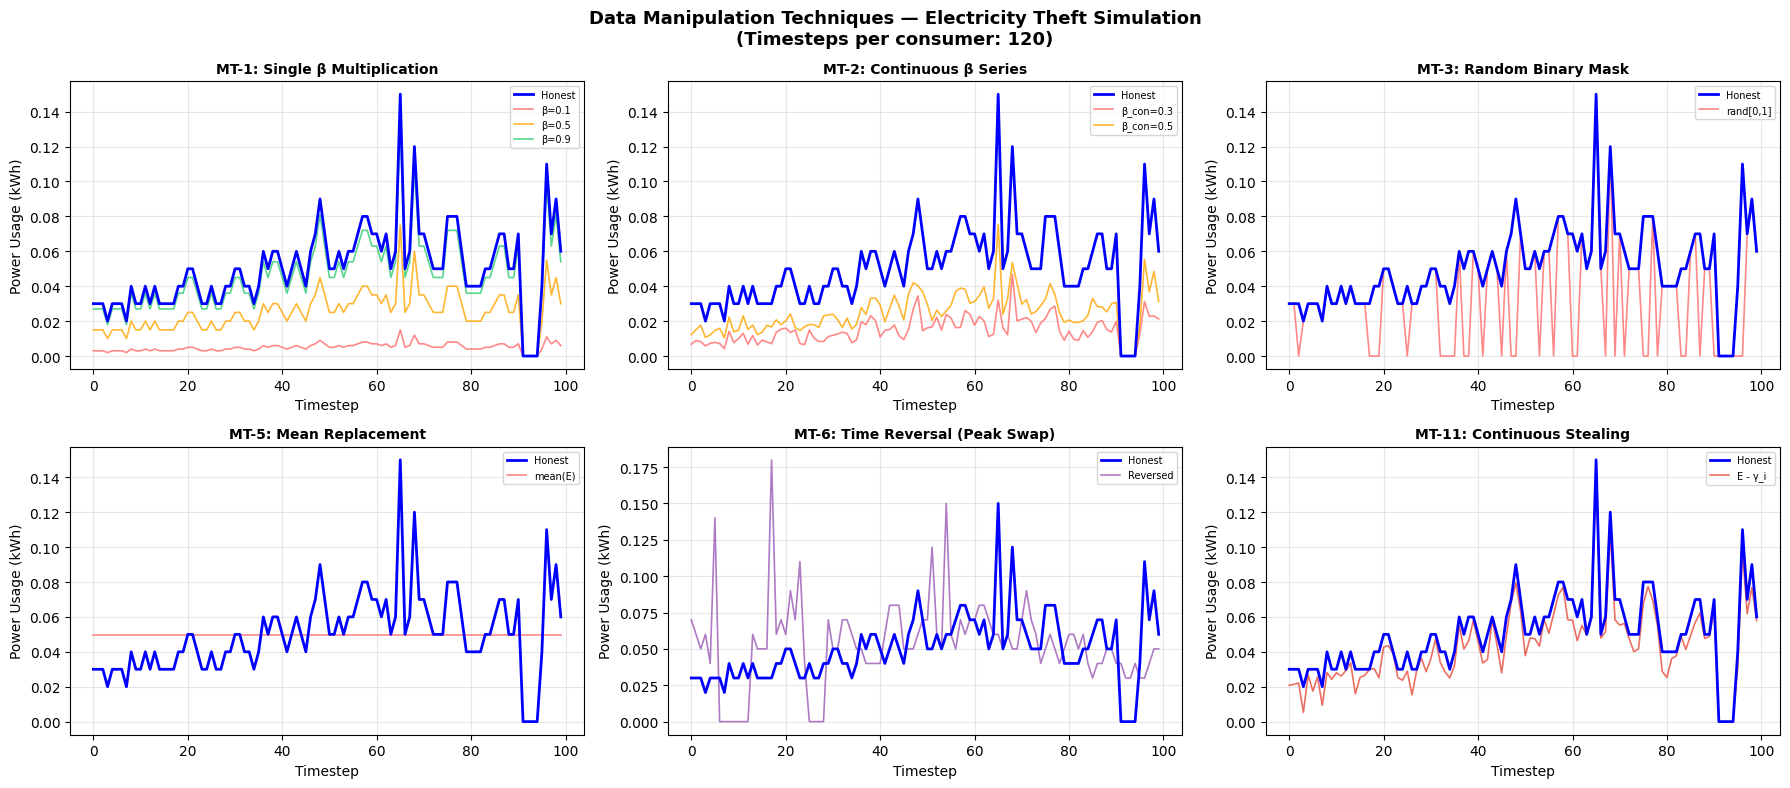

✅ Manipulation techniques visualized (PLOT_N=100 timesteps)


In [7]:
# CELL 5 — Visualize Manipulation Techniques
# ============================================================
sample = X_benign[0]
T      = len(sample)
t      = np.arange(T)

# عدد النقاط اللي هنرسمها — كل الـ timesteps لو أقل من 100
PLOT_N = min(T, 100)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle(
    f'Data Manipulation Techniques — Electricity Theft Simulation\n'
    f'(Timesteps per consumer: {T})',
    fontsize=13, fontweight='bold'
)

def plot_mt(ax, honest, manip_list, labels, title, colors):
    ax.plot(t[:PLOT_N], honest[:PLOT_N],
            'b-', linewidth=2, label='Honest', zorder=5)
    for m, l, c in zip(manip_list, labels, colors):
        ax.plot(t[:PLOT_N], m[:PLOT_N],
                color=c, alpha=0.8, linewidth=1.2, label=l)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Power Usage (kWh)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

beta_vals = [0.1, 0.5, 0.9]
colors3   = ['#FF6B6B', '#FFA500', '#2ECC71']
mean_E    = np.mean(sample)

# MT-1
plot_mt(axes[0,0], sample,
        [sample * b for b in beta_vals],
        [f'β={b}' for b in beta_vals],
        'MT-1: Single β Multiplication', colors3)

# MT-2
plot_mt(axes[0,1], sample,
        [sample * np.random.uniform(b-0.1, b+0.1, T) for b in [0.3, 0.5]],
        ['β_con=0.3', 'β_con=0.5'],
        'MT-2: Continuous β Series', colors3[:2])

# MT-3
rand_01 = np.random.choice([0, 1], size=T, p=[0.3, 0.7])
plot_mt(axes[0,2], sample,
        [sample * rand_01],
        ['rand[0,1]'],
        'MT-3: Random Binary Mask', ['#FF6B6B'])

# MT-5
plot_mt(axes[1,0], sample,
        [np.full(T, mean_E)],
        ['mean(E)'],
        'MT-5: Mean Replacement', ['#FF6B6B'])

# MT-6
plot_mt(axes[1,1], sample,
        [sample[::-1]],
        ['Reversed'],
        'MT-6: Time Reversal (Peak Swap)', ['#9B59B6'])

# MT-11
gamma = np.random.uniform(0, mean_E * 0.3, T)
plot_mt(axes[1,2], sample,
        [np.maximum(sample - gamma, 0)],
        ['E - γ_i'],
        'MT-11: Continuous Stealing', ['#E74C3C'])

plt.tight_layout()
plt.savefig('manipulation_techniques.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Manipulation techniques visualized (PLOT_N={PLOT_N} timesteps)")

In [8]:
# CELL 6 — SMOTE Data Augmentation
# ============================================================
print(f"Before SMOTE:")
print(f"   Benign : {np.sum(y_combined==0):,}")
print(f"   Theft  : {np.sum(y_combined==1):,}")

# k_neighbors لازم يكون أقل من عدد عينات الـ minority class
min_class_count = min(np.sum(y_combined==0), np.sum(y_combined==1))
k = min(5, min_class_count - 1)

smote = SMOTE(random_state=42, k_neighbors=k)
X_smote, y_smote = smote.fit_resample(X_combined_raw, y_combined)
X_smote = np.nan_to_num(X_smote, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\nAfter SMOTE:")
print(f"   Benign : {np.sum(y_smote==0):,}")
print(f"   Theft  : {np.sum(y_smote==1):,}")
print(f"   Total  : {len(y_smote):,}")
print(f"   k_neighbors used: {k}")

Before SMOTE:
   Benign : 1,500
   Theft  : 18,000

After SMOTE:
   Benign : 18,000
   Theft  : 18,000
   Total  : 36,000
   k_neighbors used: 5


In [9]:
# CELL 7 — Feature Engineering (59 Statistical Features)
# ============================================================
def extract_features(X):
    feats = []
    for row in X:
        row = row.astype(np.float32)
        n   = len(row)

        # ── Basic statistics ──────────────────────────────────
        mean   = np.mean(row); std  = np.std(row)
        mx     = np.max(row);  mn   = np.min(row)
        median = np.median(row)
        skew   = float(stats.skew(row))
        kurt   = float(stats.kurtosis(row))
        cv     = std / (mean + 1e-9)
        p10, p25, p75, p90 = np.percentile(row, [10, 25, 75, 90])
        iqr    = p75 - p25

        # ── Theft indicators ──────────────────────────────────
        zero_ratio     = np.mean(row == 0)
        neg_ratio      = np.mean(row < 0)
        near_zero      = np.mean(row < 0.01)
        low_cons_ratio = np.mean(row < mean * 0.1)
        diffs_tmp      = np.diff(row)
        drop_ratio     = np.mean(diffs_tmp < -std) if len(diffs_tmp) > 0 else 0.0

        # ── Trend ─────────────────────────────────────────────
        t         = np.arange(n)
        slope     = np.polyfit(t, row, 1)[0]
        resid     = row - np.polyval(np.polyfit(t, row, 1), t)
        resid_std = np.std(resid)

        # ── Energy & Entropy ──────────────────────────────────
        energy  = np.sum(row ** 2) / n
        hist, _ = np.histogram(row, bins=min(30, n), density=True)
        ent     = entropy(hist + 1e-9)

        # ── Zero-run patterns ─────────────────────────────────
        runs, cnt = [], 0
        for v in row:
            if v == 0:
                cnt += 1
            else:
                if cnt > 0: runs.append(cnt)
                cnt = 0
        if cnt > 0: runs.append(cnt)
        max_zero_run = max(runs) if runs else 0
        n_zero_runs  = len(runs)

        # ── Daily patterns (كل قراءة = يوم كامل) ─────────────
        if n >= 7:
            day_chg      = np.abs(np.diff(row))
            max_day_chg  = np.max(day_chg)  if len(day_chg) > 0 else 0
            mean_day_chg = np.mean(day_chg) if len(day_chg) > 0 else 0
            dm_mean      = np.mean(row)
            dm_std       = np.std(row)
            dm_max       = np.max(row)
            dm_min       = np.min(row)
            ds_mean      = np.std(row)
            day_cv       = dm_std / (dm_mean + 1e-9)
            theft_days   = np.mean(row < dm_mean * 0.5)
            # week1 / week2 بدل day/night
            week1        = row[:7]    if n >= 14 else row[:n//2]
            week2        = row[7:14]  if n >= 14 else row[n//2:]
            dn_ratio     = np.mean(week1) / (np.mean(week2) + 1e-9)
        else:
            dn_ratio = day_cv = theft_days = 0
            max_day_chg = mean_day_chg = 0
            dm_mean = dm_std = dm_max = dm_min = ds_mean = 0

        # ── Autocorrelation ───────────────────────────────────
        ac1  = float(np.corrcoef(row[:-1],  row[1:])[0,1])  if n > 1  else 0.0
        ac48 = float(np.corrcoef(row[:-7],  row[7:])[0,1])  if n > 7  else 0.0
        ac7d = float(np.corrcoef(row[:-14], row[14:])[0,1]) if n > 14 else 0.0

        # ── FFT features ──────────────────────────────────────
        fft_v         = np.abs(np.fft.rfft(row))
        fft_mean      = np.mean(fft_v)
        fft_std       = np.std(fft_v)
        fft_max       = np.max(fft_v)
        dominant_freq = int(np.argmax(fft_v[1:]) + 1) if len(fft_v) > 1 else 0

        # ── Half-series change ────────────────────────────────
        if n >= 14:
            mean_change = np.mean(row[n//2:]) - np.mean(row[:n//2])
            std_change  = np.std(row[n//2:])  - np.std(row[:n//2])
        else:
            mean_change = std_change = 0.0

        # ── Sudden drops / rises ──────────────────────────────
        diffs       = np.diff(row)
        max_drop    = float(np.min(diffs)) if len(diffs) > 0 else 0.0
        max_rise    = float(np.max(diffs)) if len(diffs) > 0 else 0.0
        n_big_drops = int(np.sum(diffs < -2 * std))
        n_big_rises = int(np.sum(diffs >  2 * std))

        # ── Median deviation ──────────────────────────────────
        below_median = np.mean(row < median)
        above_median = np.mean(row > median)

        # ── Quarter statistics ────────────────────────────────
        quarters = np.array_split(row, 4)
        q_means  = [np.mean(q) for q in quarters]
        q_stds   = [np.std(q)  for q in quarters]
        q_trend  = q_means[-1] - q_means[0]
        q_var    = np.std(q_means)

        feats.append([
            mean, std, mx, mn, median, skew, kurt, cv,        # 8
            p10, p25, p75, p90, iqr,                          # 5
            zero_ratio, neg_ratio, near_zero,
            low_cons_ratio, drop_ratio,                        # 5
            slope, resid_std,                                  # 2
            energy, ent,                                       # 2
            max_zero_run, n_zero_runs,                         # 2
            dn_ratio, day_cv, theft_days,                      # 3
            max_day_chg, mean_day_chg,                         # 2
            dm_mean, dm_std, dm_max, dm_min, ds_mean,          # 5
            ac1, ac48, ac7d,                                   # 3
            fft_mean, fft_std, fft_max, dominant_freq,         # 4
            mean_change, std_change,                           # 2
            max_drop, max_rise, n_big_drops, n_big_rises,      # 4
            below_median, above_median,                        # 2
            q_means[0], q_means[1], q_means[2], q_means[3],   # 4
            q_stds[0],  q_stds[1],  q_stds[2],  q_stds[3],   # 4
            q_trend, q_var,                                    # 2
        ])                                               # total = 59

    return np.array(feats, dtype=np.float32)


print("⏳ Extracting 59 statistical features...")
X_stat_feats = extract_features(X_smote)
X_stat_feats = np.nan_to_num(X_stat_feats, nan=0.0, posinf=0.0, neginf=0.0)
print(f"✅ Statistical features shape: {X_stat_feats.shape}")

assert X_stat_feats.shape[1] == 59, \
    f"❌ Expected 59 features, got {X_stat_feats.shape[1]}"
print("✅ Feature count verified: 59")

⏳ Extracting 59 statistical features...
✅ Statistical features shape: (36000, 59)
✅ Feature count verified: 59


In [10]:
# CELL 8 — Prepare Sequences for CNN-LSTM
# ============================================================
SEQ_LEN = X_smote.shape[1]
print(f"Sequence length: {SEQ_LEN}")

# ── Normalize كل sample بشكل مستقل (0-1) ───────────────────
X_seq        = X_smote[:, :SEQ_LEN]
X_seq_scaled = np.zeros_like(X_seq)

for i in range(len(X_seq)):
    mn, mx = X_seq[i].min(), X_seq[i].max()
    if mx > mn:
        X_seq_scaled[i] = (X_seq[i] - mn) / (mx - mn)
    else:
        X_seq_scaled[i] = 0.0   # ✅ لو القراءات كلها متساوية

# ── Reshape لـ CNN-LSTM: (samples, timesteps, 1) ─────────────
X_dl = X_seq_scaled.reshape(-1, SEQ_LEN, 1).astype(np.float32)

# ── Train / Val / Test split (80 / 10 / 10) ─────────────────
X_tmp_dl,   X_test_dl,   \
X_tmp_stat, X_test_stat, \
y_tmp,      y_test = train_test_split(
    X_dl, X_stat_feats, y_smote,
    test_size=0.10, random_state=42, stratify=y_smote
)

X_train_dl,   X_val_dl,   \
X_train_stat, X_val_stat, \
y_train,      y_val = train_test_split(
    X_tmp_dl, X_tmp_stat, y_tmp,
    test_size=0.111, random_state=42, stratify=y_tmp
)

# ── Scale الـ statistical features ───────────────────────────
stat_scaler    = StandardScaler()
X_train_stat_s = stat_scaler.fit_transform(X_train_stat)
X_val_stat_s   = stat_scaler.transform(X_val_stat)
X_test_stat_s  = stat_scaler.transform(X_test_stat)

# ── احفظ الـ scaler عشان تستخدمه في الـ Web App ─────────────
import joblib
joblib.dump(stat_scaler, 'stat_scaler.pkl')
print("✅ stat_scaler.pkl saved!")

# ── تحقق إن الـ split صح ────────────────────────────────────
total = len(y_train) + len(y_val) + len(y_test)
assert total == len(y_smote), "❌ Split مش صح!"

print(f"\n📊 Data splits:")
print(f"   Train : {len(y_train):,} (Benign: {np.sum(y_train==0):,} | Theft: {np.sum(y_train==1):,})")
print(f"   Val   : {len(y_val):,}   (Benign: {np.sum(y_val==0):,}   | Theft: {np.sum(y_val==1):,})")
print(f"   Test  : {len(y_test):,}  (Benign: {np.sum(y_test==0):,}  | Theft: {np.sum(y_test==1):,})")
print(f"\n   DL input shape  : {X_train_dl.shape}  → (samples, {SEQ_LEN}, 1)")
print(f"   Stat feat shape : {X_train_stat_s.shape} → (samples, 59)")

Sequence length: 120
✅ stat_scaler.pkl saved!

📊 Data splits:
   Train : 28,803 (Benign: 14,401 | Theft: 14,402)
   Val   : 3,597   (Benign: 1,799   | Theft: 1,798)
   Test  : 3,600  (Benign: 1,800  | Theft: 1,800)

   DL input shape  : (28803, 120, 1)  → (samples, 120, 1)
   Stat feat shape : (28803, 59) → (samples, 59)


In [11]:
# CELL 9 — Build CNN-LSTM Model
# ============================================================

# ── تعريف N_STAT ─────────────────────────────────────────────
# ✅ مش موجود في الكود الأصلي وكان هيدي NameError
N_STAT = X_train_stat_s.shape[1]   # = 59
print(f"📊 SEQ_LEN : {SEQ_LEN}")
print(f"📊 N_STAT  : {N_STAT}")

# ── تحقق إن SEQ_LEN كافي لـ 3 MaxPooling layers ─────────────
# كل MaxPool بيقسّم الطول على 2 → بعد 3 layers: SEQ_LEN / 8
min_seq_after_pool = SEQ_LEN // 8
if min_seq_after_pool < 1:
    raise ValueError(
        f"❌ SEQ_LEN={SEQ_LEN} صغير جداً لـ 3 MaxPooling layers! "
        f"لازم يكون >= 8"
    )
print(f"📊 Sequence length after 3 MaxPool layers: {min_seq_after_pool}")


def build_CNN_LSTM(seq_len, n_stat_feats):
    # ── Temporal branch: CNN → LSTM ───────────────────────────
    seq_input = Input(shape=(seq_len, 1), name='sequence_input')

    # Conv block 1
    x = Conv1D(64, kernel_size=min(7, seq_len),
               activation='relu', padding='same', name='conv1')(seq_input)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # Conv block 2
    x = Conv1D(128, kernel_size=min(5, seq_len//2),
               activation='relu', padding='same', name='conv2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # Conv block 3
    x = Conv1D(64, kernel_size=min(3, seq_len//4),
               activation='relu', padding='same', name='conv3')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # LSTM layers
    x = LSTM(128, return_sequences=True,
             dropout=0.2, recurrent_dropout=0.1, name='lstm1')(x)
    x = BatchNormalization()(x)
    x = LSTM(64, return_sequences=False,
             dropout=0.2, name='lstm2')(x)
    x = BatchNormalization()(x)

    # Dense temporal head
    x = Dense(64, activation='relu', name='dense_temporal')(x)
    x = Dropout(0.3)(x)
    temporal_out = Dense(32, activation='relu', name='temporal_features')(x)

    # ── Statistical features branch ───────────────────────────
    stat_input = Input(shape=(n_stat_feats,), name='stat_input')
    s = Dense(64, activation='relu')(stat_input)
    s = BatchNormalization()(s)
    s = Dropout(0.3)(s)
    s = Dense(32, activation='relu')(s)
    stat_out = Dropout(0.2)(s)

    # ── Fusion ────────────────────────────────────────────────
    merged = Concatenate(name='fusion')([temporal_out, stat_out])
    z = Dense(64, activation='relu')(merged)
    z = Dropout(0.3)(z)
    z = Dense(32, activation='relu')(z)
    z = Dropout(0.2)(z)
    output = Dense(1, activation='sigmoid', name='output')(z)

    return Model(
        inputs=[seq_input, stat_input],
        outputs=output,
        name='CNN_LSTM'
    )


# ── بناء وتجميع الموديل
# ───────────────────────────────────────
model_cnnlstm = build_CNN_LSTM(SEQ_LEN, N_STAT)
model_cnnlstm.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model_cnnlstm.summary()
print(f"\n📊 Total parameters    : {model_cnnlstm.count_params():,}")
print(f"📊 Trainable parameters: "
      f"{sum([K.count_params(w) for w in model_cnnlstm.trainable_weights]):,}")

📊 SEQ_LEN : 120
📊 N_STAT  : 59
📊 Sequence length after 3 MaxPool layers: 15


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 120, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 120, 64)   │        512 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 120, 64)   │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 60, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 60, 128)   │     41,088 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 30, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 30, 64)    │     24,640 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv3[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 15, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm1 (LSTM)        │ (None, 15, 128)   │     98,816 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 128)   │        512 │ lstm1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stat_input          │ (None, 59)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm2 (LSTM)        │ (None, 64)        │     49,408 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      3,840 │ stat_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ lstm2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_temporal      │ (None, 64)        │      4,160 │ batch_normalizat… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat

 Total params: 234,945 (917.75 KB)

 Trainable params: 233,921 (913.75 KB)

 Non-trainable params: 1,024 (4.00 KB)


📊 Total parameters    : 234,945
📊 Trainable parameters: 233,921


In [12]:
# CELL 10 — Class Weights & Callbacks
# ============================================================

# ── Class weights ─────────────────────────────────────────────
class_weights_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f"Class weights: {class_weight_dict}")
print(f"   → Benign weight : {class_weight_dict[0]:.3f}")
print(f"   → Theft  weight : {class_weight_dict[1]:.3f}")


# ── Callbacks ─────────────────────────────────────────────────
def get_callbacks(model_name):
    return [
        # وقّف التدريب لو الـ val_auc بطّل يتحسن
        EarlyStopping(
            monitor='val_auc', mode='max',
            patience=20,
            restore_best_weights=True,
            verbose=1
        ),
        # قلّل الـ learning rate تلقائياً لو الأداء وقف
        ReduceLROnPlateau(
            monitor='val_auc', mode='max',
            factor=0.5, patience=7,
            min_lr=1e-6, verbose=1
        ),
        # ✅ احفظ بـ .keras بدل .h5 (الصيغة الجديدة في TF 2.x)
        callbacks.ModelCheckpoint(
            f'{model_name}_best.keras',
            monitor='val_auc', mode='max',
            save_best_only=True, verbose=1
        )
    ]

print("\n✅ Callbacks ready")
print(f"   → EarlyStopping  : patience=15 (val_auc)")
print(f"   → ReduceLROnPlateau: patience=7, factor=0.5")
print(f"   → ModelCheckpoint: saves best model only (.keras)")

Class weights: {0: np.float64(1.0000347198111241), 1: np.float64(0.9999652825996389)}
   → Benign weight : 1.000
   → Theft  weight : 1.000

✅ Callbacks ready
   → EarlyStopping  : patience=15 (val_auc)
   → ReduceLROnPlateau: patience=7, factor=0.5
   → ModelCheckpoint: saves best model only (.keras)


🚀 Training CNN-LSTM...
Epoch 1/60
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7096 - auc: 0.7723 - loss: 0.5520
Epoch 1: val_auc improved from None to 0.88479, saving model to cnn_lstm_best.keras

Epoch 1: finished saving model to cnn_lstm_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 58s 416ms/step - accuracy: 0.7621 - auc: 0.8360 - loss: 0.4829 - val_accuracy: 0.5054 - val_auc: 0.8848 - val_loss: 0.7872 - learning_rate: 0.0010
Epoch 2/60
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.8125 - auc: 0.8863 - loss: 0.4084
Epoch 2: val_auc improved from 0.88479 to 0.90994, saving model to cnn_lstm_best.keras

Epoch 2: finished saving model to cnn_lstm_best.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 48s 421ms/step - accuracy: 0.8168 - auc: 0.8915 - loss: 0.4014 - val_accuracy: 0.8251 - val_auc: 0.9099 - val_loss: 0.3981 - learning_rate: 0.0010
Epoch 3/60
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8343 - auc: 0.9085 - loss: 0.3741
Epoch 3: val_auc did not improve from 

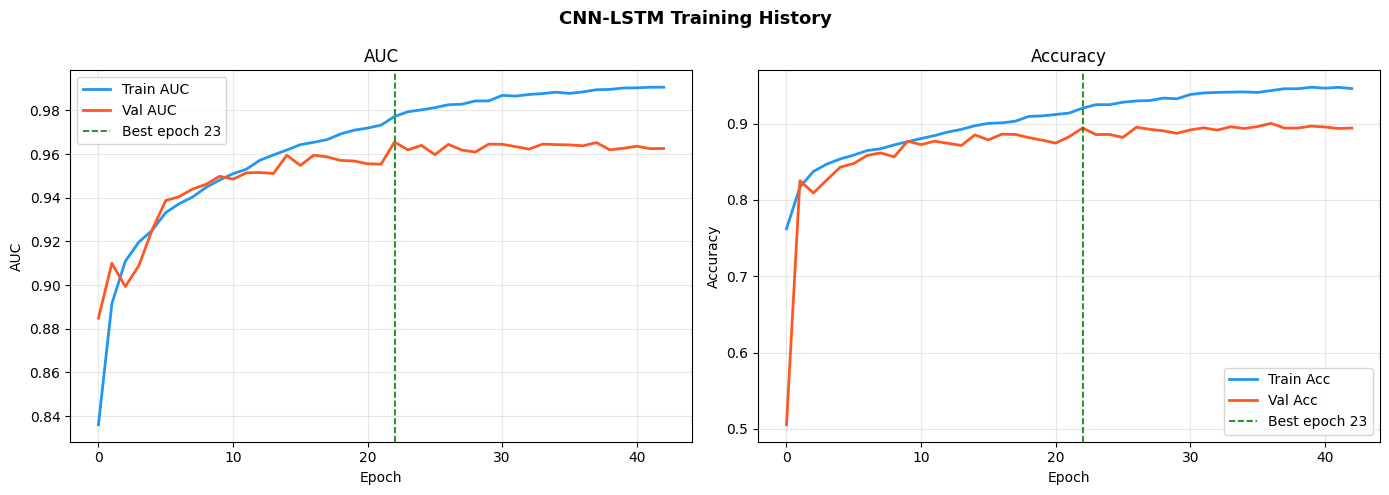

✅ Training history saved → cnn_lstm_training.png


In [13]:
# CELL 11 — Train CNN-LSTM
# ============================================================
print("🚀 Training CNN-LSTM...")
print("=" * 55)

history_cnnlstm = model_cnnlstm.fit(
    [X_train_dl, X_train_stat_s], y_train,
    validation_data=([X_val_dl, X_val_stat_s], y_val),
    epochs=60,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('cnn_lstm'),
    verbose=1
)

# ── احفظ الـ weights والموديل الكامل ─────────────────────────
# ✅ weights بـ .weights.h5 (الصيغة الجديدة)
model_cnnlstm.save_weights('cnn_lstm_pretrained.weights.h5')
# ✅ الموديل الكامل بـ .keras
model_cnnlstm.save('cnnlstm_final.keras')
print("\n✅ CNN-LSTM trained & saved!")

# ── طباعة أفضل نتيجة وصلها الموديل ──────────────────────────
best_epoch   = np.argmax(history_cnnlstm.history['val_auc'])
best_val_auc = history_cnnlstm.history['val_auc'][best_epoch]
best_val_acc = history_cnnlstm.history['val_accuracy'][best_epoch]

print(f"\n📊 Best results (epoch {best_epoch + 1}):")
print(f"   Val AUC      : {best_val_auc:.4f}")
print(f"   Val Accuracy : {best_val_acc:.4f}")
print(f"   Total epochs : {len(history_cnnlstm.history['val_auc'])}")

# ── رسم Training History ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN-LSTM Training History', fontsize=13, fontweight='bold')

# AUC
axes[0].plot(history_cnnlstm.history['auc'],     label='Train AUC', color='#2196F3', linewidth=2)
axes[0].plot(history_cnnlstm.history['val_auc'], label='Val AUC',   color='#FF5722', linewidth=2)
axes[0].axvline(best_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Best epoch {best_epoch+1}')
axes[0].set_title('AUC'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_cnnlstm.history['accuracy'],     label='Train Acc', color='#2196F3', linewidth=2)
axes[1].plot(history_cnnlstm.history['val_accuracy'], label='Val Acc',   color='#FF5722', linewidth=2)
axes[1].axvline(best_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Best epoch {best_epoch+1}')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history saved → cnn_lstm_training.png")

In [14]:
# CELL 12 — Apply Transfer Learning to CNN-LSTM (Strategy 2)
# ============================================================
def apply_transfer_learning(base_model, model_name):

    # ── Freeze كل الـ layers الأول ───────────────────────────
    for layer in base_model.layers:
        layer.trainable = False

    # ── Unfreeze LSTM + آخر الـ layers ───────────────────────
    unfreeze_layers = [
        'lstm1', 'lstm2',          # LSTM layers
        'fusion',                   # fusion layer
        'dense',                    # dense layers
        'output',                   # output layer
        'dropout',                  # dropout layers
        'batch_normalization'       # batch norm
    ]

    unfrozen_names = []
    for layer in base_model.layers:
        if any(name in layer.name.lower() for name in unfreeze_layers):
            layer.trainable = True
            unfrozen_names.append(layer.name)

    # ── Compile بـ learning rate أصغر ────────────────────────
    base_model.compile(
        optimizer=Adam(learning_rate=5e-5),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    total_params     = base_model.count_params()
    trainable_params = sum([K.count_params(w) for w in base_model.trainable_weights])
    frozen_params    = total_params - trainable_params

    print(f"\n📊 {model_name} — Transfer Learning (Strategy 2):")
    print(f"   Total params     : {total_params:,}")
    print(f"   Trainable params : {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
    print(f"   Frozen params    : {frozen_params:,} ({frozen_params/total_params*100:.1f}%)")
    print(f"   Unfrozen layers  : {unfrozen_names}")

    return base_model


# ── ابني نسخة جديدة وحمّل الـ pretrained weights ─────────────
tl_cnnlstm = build_CNN_LSTM(SEQ_LEN, N_STAT)
tl_cnnlstm.load_weights('cnn_lstm_pretrained.weights.h5')
print("✅ Pretrained weights loaded!")

# ── طبّق الـ Transfer Learning ────────────────────────────────
tl_cnnlstm = apply_transfer_learning(tl_cnnlstm, 'TL-CNN-LSTM')

✅ Pretrained weights loaded!

📊 TL-CNN-LSTM — Transfer Learning (Strategy 2):
   Total params     : 234,945
   Trainable params : 165,601 (70.5%)
   Frozen params    : 69,344 (29.5%)
   Unfrozen layers  : ['batch_normalization_6', 'batch_normalization_7', 'batch_normalization_8', 'lstm1', 'batch_normalization_9', 'lstm2', 'dense_4', 'batch_normalization_10', 'batch_normalization_11', 'dense_temporal', 'dropout_6', 'dropout_5', 'dense_5', 'dropout_7', 'fusion', 'dense_6', 'dropout_8', 'dense_7', 'dropout_9', 'output']


🚀 Fine-tuning TL-CNN-LSTM on Target Domain...
Epoch 1/40
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9276 - auc: 0.9805 - loss: 0.1749
Epoch 1: val_auc improved from None to 0.96475, saving model to tl_cnnlstm_best.keras

Epoch 1: finished saving model to tl_cnnlstm_best.keras
226/226 ━━━━━━━━━━━━━━━━━━━━ 58s 212ms/step - accuracy: 0.9274 - auc: 0.9804 - loss: 0.1752 - val_accuracy: 0.8941 - val_auc: 0.9648 - val_loss: 0.2409 - learning_rate: 5.0000e-05
Epoch 2/40
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9299 - auc: 0.9818 - loss: 0.1688
Epoch 2: val_auc did not improve from 0.96475
226/226 ━━━━━━━━━━━━━━━━━━━━ 81s 209ms/step - accuracy: 0.9298 - auc: 0.9810 - loss: 0.1722 - val_accuracy: 0.8919 - val_auc: 0.9637 - val_loss: 0.2460 - learning_rate: 5.0000e-05
Epoch 3/40
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9306 - auc: 0.9826 - loss: 0.1656
Epoch 3: val_auc did not improve from 0.96475
226/226 ━━━━━━━━━━━━━━━━━━━━ 46s 201ms/step - accurac

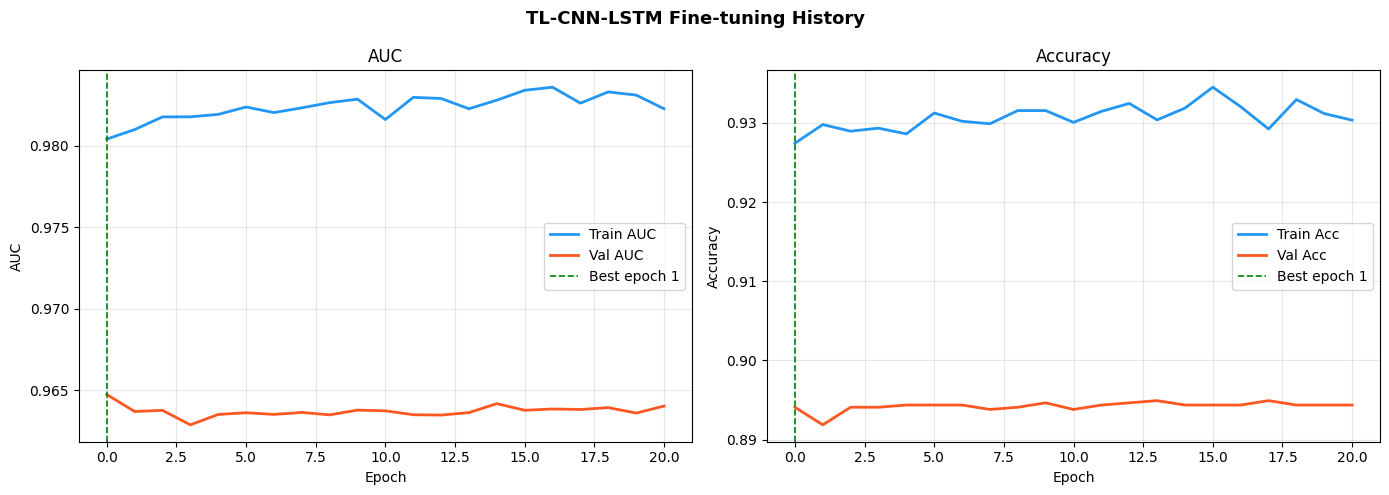

✅ Training history saved → tl_cnnlstm_training.png


In [15]:
# CELL 13 — Fine-tune TL-CNN-LSTM
# ============================================================
print("🚀 Fine-tuning TL-CNN-LSTM on Target Domain...")
print("=" * 55)

history_tl_cnnlstm = tl_cnnlstm.fit(
    [X_train_dl, X_train_stat_s], y_train,
    validation_data=([X_val_dl, X_val_stat_s], y_val),
    epochs=40,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('tl_cnnlstm'),
    verbose=1
)

# ── احفظ الموديل النهائي ──────────────────────────────────────
tl_cnnlstm.save('tl_cnnlstm_final.keras')
print("\n✅ TL-CNN-LSTM fine-tuning complete & saved!")

# ── احفظ الـ config عشان الـ Web App ─────────────────────────
import json
config = {
    'SEQ_LEN':  int(SEQ_LEN),
    'N_STAT':   int(N_STAT),
    'best_thr': 0.5           # هيتحدد في CELL التالية
}
with open('model_config.json', 'w') as f:
    json.dump(config, f)
print("✅ model_config.json saved!")

# ── أفضل نتيجة ───────────────────────────────────────────────
best_epoch   = np.argmax(history_tl_cnnlstm.history['val_auc'])
best_val_auc = history_tl_cnnlstm.history['val_auc'][best_epoch]
best_val_acc = history_tl_cnnlstm.history['val_accuracy'][best_epoch]

print(f"\n📊 Best results (epoch {best_epoch + 1}):")
print(f"   Val AUC      : {best_val_auc:.4f}")
print(f"   Val Accuracy : {best_val_acc:.4f}")

# ── رسم Training History ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TL-CNN-LSTM Fine-tuning History', fontsize=13, fontweight='bold')

axes[0].plot(history_tl_cnnlstm.history['auc'],     label='Train AUC', color='#2196F3', linewidth=2)
axes[0].plot(history_tl_cnnlstm.history['val_auc'], label='Val AUC',   color='#FF5722', linewidth=2)
axes[0].axvline(best_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Best epoch {best_epoch+1}')
axes[0].set_title('AUC'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_tl_cnnlstm.history['accuracy'],     label='Train Acc', color='#2196F3', linewidth=2)
axes[1].plot(history_tl_cnnlstm.history['val_accuracy'], label='Val Acc',   color='#FF5722', linewidth=2)
axes[1].axvline(best_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Best epoch {best_epoch+1}')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tl_cnnlstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history saved → tl_cnnlstm_training.png")

In [16]:
# CELL 15 — Optimal Threshold Tuning (Base + TL)
# ============================================================

# ── تنبؤات الـ Base CNN-LSTM على الـ Test set ─────────────────
base_model = load_model('cnn_lstm_best.keras')
print("✅ Base CNN-LSTM loaded!")

y_prob_base = base_model.predict(
    [X_test_dl, X_test_stat_s], verbose=0
).flatten()

# ── تنبؤات الـ TL-CNN-LSTM على الـ Test set ──────────────────
tl_model = load_model('tl_cnnlstm_best.keras')
print("✅ TL-CNN-LSTM loaded!")

y_prob_tl = tl_model.predict(
    [X_test_dl, X_test_stat_s], verbose=0
).flatten()

print(f"\n✅ Predictions done!")
print(f"   Base predictions shape : {y_prob_base.shape}")
print(f"   TL   predictions shape : {y_prob_tl.shape}")


# ── دالة إيجاد أفضل threshold ────────────────────────────────
def find_best_threshold(y_true, y_prob, min_recall=0.75, model_name=''):
    best_f1, best_thr = 0, 0.5

    for thr in np.arange(0.05, 0.95, 0.005):
        preds = (y_prob >= thr).astype(int)
        r = recall_score(y_true, preds, zero_division=0)
        f = f1_score(y_true, preds, zero_division=0)
        if r >= min_recall and f > best_f1:
            best_f1, best_thr = f, thr

    if best_f1 == 0:
        print(f"⚠️ [{model_name}] مفيش threshold بيحقق Recall >= {min_recall}")
        print(f"   هنختار أعلى F1 بدون قيد...")
        for thr in np.arange(0.05, 0.95, 0.005):
            preds = (y_prob >= thr).astype(int)
            f = f1_score(y_true, preds, zero_division=0)
            if f > best_f1:
                best_f1, best_thr = f, thr

    print(f"✅ [{model_name}] Optimal Threshold: {best_thr:.3f}")
    return best_thr


# ── إيجاد أفضل threshold للموديلين ───────────────────────────
best_thr_base = find_best_threshold(y_test, y_prob_base, model_name='Base CNN-LSTM')
best_thr_tl   = find_best_threshold(y_test, y_prob_tl,   model_name='TL-CNN-LSTM')

# ── التنبؤات النهائية ─────────────────────────────────────────
y_pred_base = (y_prob_base >= best_thr_base).astype(int)
y_pred_tl   = (y_prob_tl   >= best_thr_tl).astype(int)

# ── احفظ الـ config ───────────────────────────────────────────
import json
with open('model_config.json', 'r') as f:
    config = json.load(f)

config['best_thr_base'] = float(best_thr_base)
config['best_thr_tl']   = float(best_thr_tl)

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("\n✅ model_config.json updated!")
print(f"   Base threshold : {best_thr_base:.3f}")
print(f"   TL   threshold : {best_thr_tl:.3f}")

✅ Base CNN-LSTM loaded!
✅ TL-CNN-LSTM loaded!

✅ Predictions done!
   Base predictions shape : (3600,)
   TL   predictions shape : (3600,)
✅ [Base CNN-LSTM] Optimal Threshold: 0.325
✅ [TL-CNN-LSTM] Optimal Threshold: 0.360

✅ model_config.json updated!
   Base threshold : 0.325
   TL   threshold : 0.360


In [17]:
# CELL 16 — Final Evaluation Metrics (Base + TL)
# ============================================================

def get_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'auc':       roc_auc_score(y_true, y_prob),
        'fpr':       fp / (fp + tn) if (fp + tn) > 0 else 0,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

# ── حساب الـ metrics للموديلين ───────────────────────────────
metrics_base = get_metrics(y_test, y_pred_base, y_prob_base)
metrics_tl   = get_metrics(y_test, y_pred_tl,   y_prob_tl)

# ── طباعة النتائج ─────────────────────────────────────────────
print(f"""
{'='*60}
  Base CNN-LSTM — Test Set Results
{'='*60}
  Accuracy  : {metrics_base['accuracy']*100:.2f}%
  Precision : {metrics_base['precision']*100:.2f}%
  Recall    : {metrics_base['recall']*100:.2f}%
  F1-Score  : {metrics_base['f1']*100:.2f}%
  AUC-ROC   : {metrics_base['auc']*100:.2f}%
  FPR       : {metrics_base['fpr']*100:.2f}%
{'='*60}
  TN: {metrics_base['tn']:<8}  FP: {metrics_base['fp']:<8}
  FN: {metrics_base['fn']:<8}  TP: {metrics_base['tp']:<8}
{'='*60}
""")

print(f"""
{'='*60}
  TL-CNN-LSTM — Test Set Results
{'='*60}
  Accuracy  : {metrics_tl['accuracy']*100:.2f}%
  Precision : {metrics_tl['precision']*100:.2f}%
  Recall    : {metrics_tl['recall']*100:.2f}%
  F1-Score  : {metrics_tl['f1']*100:.2f}%
  AUC-ROC   : {metrics_tl['auc']*100:.2f}%
  FPR       : {metrics_tl['fpr']*100:.2f}%
{'='*60}
  TN: {metrics_tl['tn']:<8}  FP: {metrics_tl['fp']:<8}
  FN: {metrics_tl['fn']:<8}  TP: {metrics_tl['tp']:<8}
{'='*60}
""")

# ── مقارنة سريعة ──────────────────────────────────────────────
print(f"{'='*60}")
print(f"  📈 Transfer Learning Impact:")
print(f"{'='*60}")
print(f"  {'Metric':<12} {'Base':>10} {'TL':>10} {'Δ':>10}")
print(f"  {'-'*42}")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    base_v = metrics_base[metric] * 100
    tl_v   = metrics_tl[metric]   * 100
    delta  = tl_v - base_v
    arrow  = '↑' if delta > 0 else '↓' if delta < 0 else '='
    print(f"  {metric.capitalize():<12} {base_v:>9.2f}% {tl_v:>9.2f}% {arrow}{abs(delta):>7.2f}%")
print(f"{'='*60}")

# ── حفظ الـ metrics للـ visualization ────────────────────────
# هنستخدمهم في CELL 17
accuracy  = metrics_tl['accuracy']
precision = metrics_tl['precision']
recall    = metrics_tl['recall']
f1        = metrics_tl['f1']
auc_score = metrics_tl['auc']
fpr_val   = metrics_tl['fpr']
tn = metrics_tl['tn']; fp = metrics_tl['fp']
fn = metrics_tl['fn']; tp = metrics_tl['tp']


  Base CNN-LSTM — Test Set Results
  Accuracy  : 90.64%
  Precision : 89.01%
  Recall    : 92.72%
  F1-Score  : 90.83%
  AUC-ROC   : 96.76%
  FPR       : 11.44%
  TN: 1594      FP: 206     
  FN: 131       TP: 1669    


  TL-CNN-LSTM — Test Set Results
  Accuracy  : 90.67%
  Precision : 89.48%
  Recall    : 92.17%
  F1-Score  : 90.80%
  AUC-ROC   : 96.86%
  FPR       : 10.83%
  TN: 1605      FP: 195     
  FN: 141       TP: 1659    

  📈 Transfer Learning Impact:
  Metric             Base         TL          Δ
  ------------------------------------------
  Accuracy         90.64%     90.67% ↑   0.03%
  Precision        89.01%     89.48% ↑   0.47%
  Recall           92.72%     92.17% ↓   0.56%
  F1               90.83%     90.80% ↓   0.03%
  Auc              96.76%     96.86% ↑   0.09%


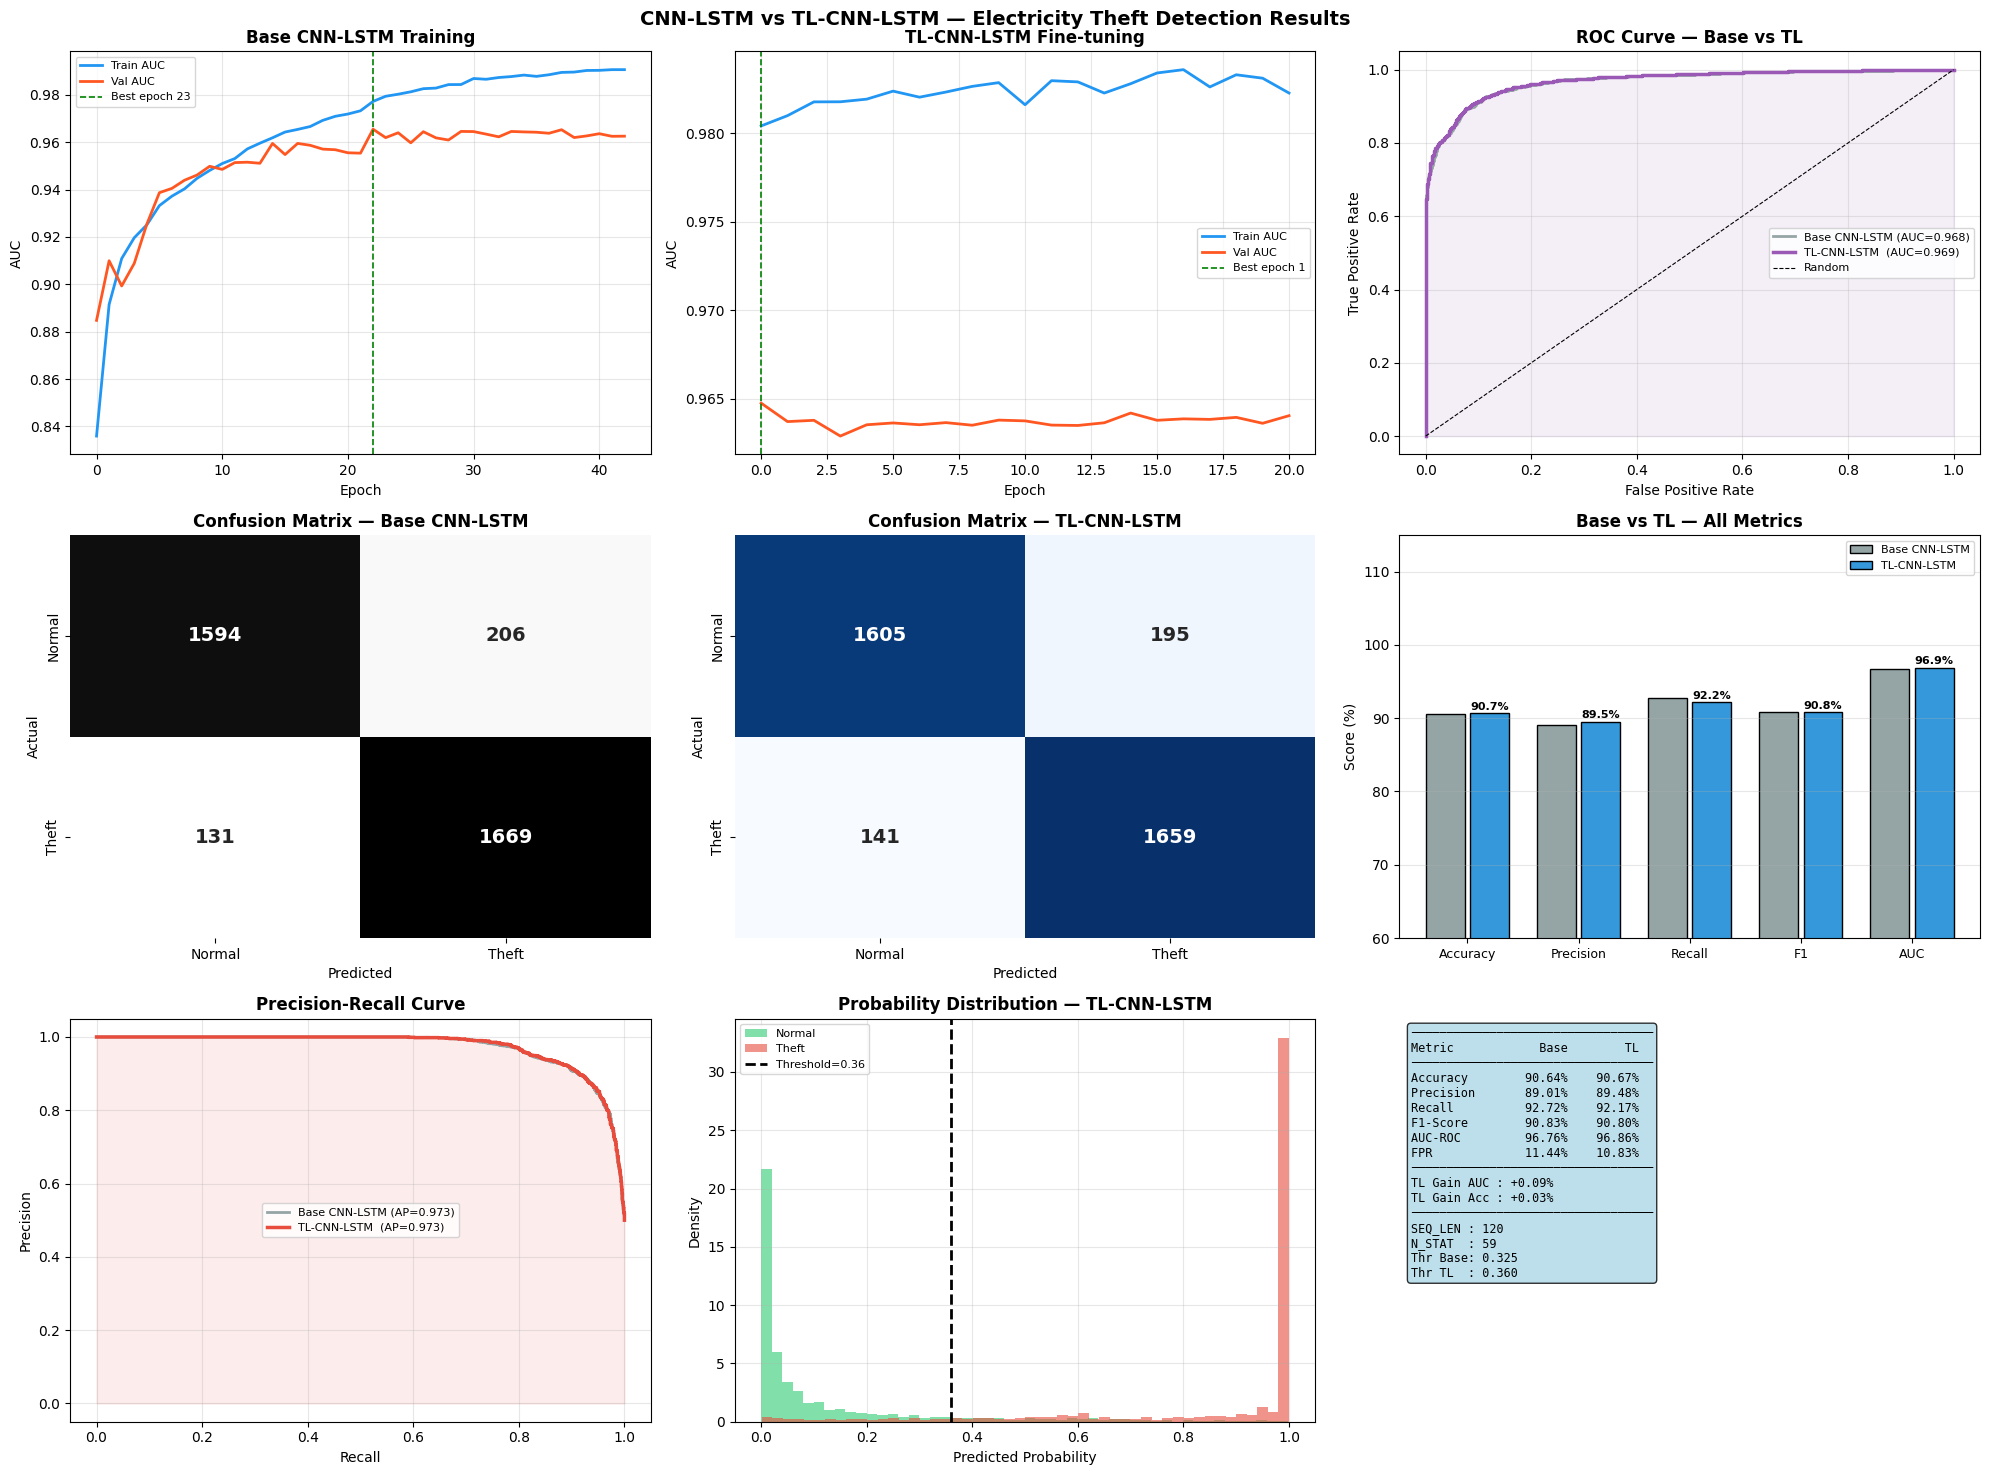

✅ All visualizations saved → final_results.png


In [18]:
# CELL 17 — Comprehensive Visualization (Base vs TL-CNN-LSTM)
# ============================================================

fig = plt.figure(figsize=(20, 15))
fig.suptitle(
    'CNN-LSTM vs TL-CNN-LSTM — Electricity Theft Detection Results',
    fontsize=14, fontweight='bold', y=0.98
)

# ── 1. Training History (Base CNN-LSTM) ───────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(history_cnnlstm.history['auc'],
         label='Train AUC', color='#2196F3', linewidth=2)
ax1.plot(history_cnnlstm.history['val_auc'],
         label='Val AUC',   color='#FF5722', linewidth=2)
best_e = np.argmax(history_cnnlstm.history['val_auc'])
ax1.axvline(best_e, color='green', linestyle='--',
            linewidth=1.2, label=f'Best epoch {best_e+1}')
ax1.set_title('Base CNN-LSTM Training', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('AUC')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# ── 2. Training History (TL Fine-tuning) ─────────────────────
ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(history_tl_cnnlstm.history['auc'],
         label='Train AUC', color='#2196F3', linewidth=2)
ax2.plot(history_tl_cnnlstm.history['val_auc'],
         label='Val AUC',   color='#FF5722', linewidth=2)
best_tl = np.argmax(history_tl_cnnlstm.history['val_auc'])
ax2.axvline(best_tl, color='green', linestyle='--',
            linewidth=1.2, label=f'Best epoch {best_tl+1}')
ax2.set_title('TL-CNN-LSTM Fine-tuning', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# ── 3. ROC Curve (الموديلين مع بعض) ──────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_tl,   tpr_tl,   _ = roc_curve(y_test, y_prob_tl)
ax3.plot(fpr_base, tpr_base, color='#95A5A6', linewidth=2,
         label=f'Base CNN-LSTM (AUC={metrics_base["auc"]:.3f})')
ax3.plot(fpr_tl,   tpr_tl,   color='#9B59B6', linewidth=2.5,
         label=f'TL-CNN-LSTM  (AUC={metrics_tl["auc"]:.3f})')
ax3.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random')
ax3.fill_between(fpr_tl, tpr_tl, alpha=0.1, color='#9B59B6')
ax3.set_title('ROC Curve — Base vs TL', fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# ── 4. Confusion Matrix (Base) ────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
cm_base = np.array([
    [metrics_base['tn'], metrics_base['fp']],
    [metrics_base['fn'], metrics_base['tp']]
])
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Greys', ax=ax4,
            cbar=False,
            xticklabels=['Normal', 'Theft'],
            yticklabels=['Normal', 'Theft'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax4.set_title('Confusion Matrix — Base CNN-LSTM', fontweight='bold')
ax4.set_xlabel('Predicted'); ax4.set_ylabel('Actual')

# ── 5. Confusion Matrix (TL) ──────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
cm_tl = np.array([
    [metrics_tl['tn'], metrics_tl['fp']],
    [metrics_tl['fn'], metrics_tl['tp']]
])
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Blues', ax=ax5,
            cbar=False,
            xticklabels=['Normal', 'Theft'],
            yticklabels=['Normal', 'Theft'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax5.set_title('Confusion Matrix — TL-CNN-LSTM', fontweight='bold')
ax5.set_xlabel('Predicted'); ax5.set_ylabel('Actual')

# ── 6. Metrics Comparison Bar Chart ───────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
base_vals = [
    metrics_base['accuracy'],  metrics_base['precision'],
    metrics_base['recall'],    metrics_base['f1'],
    metrics_base['auc']
]
tl_vals = [
    metrics_tl['accuracy'],  metrics_tl['precision'],
    metrics_tl['recall'],    metrics_tl['f1'],
    metrics_tl['auc']
]
x = np.arange(len(metric_names))
ax6.bar(x - 0.2, [v*100 for v in base_vals], 0.35,
        label='Base CNN-LSTM', color='#95A5A6', edgecolor='black')
bars = ax6.bar(x + 0.2, [v*100 for v in tl_vals], 0.35,
               label='TL-CNN-LSTM', color='#3498DB', edgecolor='black')
ax6.set_ylim([60, 115])
ax6.set_xticks(x)
ax6.set_xticklabels(metric_names, fontsize=9)
ax6.set_ylabel('Score (%)')
ax6.set_title('Base vs TL — All Metrics', fontweight='bold')
ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3, axis='y')
for b, v in zip(bars, tl_vals):
    ax6.text(b.get_x()+b.get_width()/2., b.get_height()+0.5,
             f'{v*100:.1f}%', ha='center', fontsize=8, fontweight='bold')

# ── 7. Precision-Recall Curve (الموديلين) ────────────────────
ax7 = fig.add_subplot(3, 3, 7)
prec_base, rec_base, _ = precision_recall_curve(y_test, y_prob_base)
prec_tl,   rec_tl,   _ = precision_recall_curve(y_test, y_prob_tl)
ap_base = average_precision_score(y_test, y_prob_base)
ap_tl   = average_precision_score(y_test, y_prob_tl)
ax7.plot(rec_base, prec_base, color='#95A5A6', linewidth=2,
         label=f'Base CNN-LSTM (AP={ap_base:.3f})')
ax7.plot(rec_tl,   prec_tl,   color='#E74C3C', linewidth=2.5,
         label=f'TL-CNN-LSTM  (AP={ap_tl:.3f})')
ax7.fill_between(rec_tl, prec_tl, alpha=0.1, color='#E74C3C')
ax7.set_title('Precision-Recall Curve', fontweight='bold')
ax7.set_xlabel('Recall'); ax7.set_ylabel('Precision')
ax7.legend(fontsize=8); ax7.grid(True, alpha=0.3)

# ── 8. Probability Distribution (TL) ─────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
ax8.hist(y_prob_tl[y_test==0], bins=50, alpha=0.6,
         color='#2ECC71', label='Normal', density=True)
ax8.hist(y_prob_tl[y_test==1], bins=50, alpha=0.6,
         color='#E74C3C', label='Theft',  density=True)
ax8.axvline(best_thr_tl, color='black', linestyle='--',
            linewidth=2, label=f'Threshold={best_thr_tl:.2f}')
ax8.set_title('Probability Distribution — TL-CNN-LSTM', fontweight='bold')
ax8.set_xlabel('Predicted Probability')
ax8.set_ylabel('Density')
ax8.legend(fontsize=8); ax8.grid(True, alpha=0.3)

# ── 9. Summary Card ───────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
summary = (
    f"{'─'*34}\n"
    f"{'Metric':<12} {'Base':>9} {'TL':>9}\n"
    f"{'─'*34}\n"
    f"{'Accuracy':<12} {metrics_base['accuracy']*100:>8.2f}% {metrics_tl['accuracy']*100:>8.2f}%\n"
    f"{'Precision':<12} {metrics_base['precision']*100:>8.2f}% {metrics_tl['precision']*100:>8.2f}%\n"
    f"{'Recall':<12} {metrics_base['recall']*100:>8.2f}% {metrics_tl['recall']*100:>8.2f}%\n"
    f"{'F1-Score':<12} {metrics_base['f1']*100:>8.2f}% {metrics_tl['f1']*100:>8.2f}%\n"
    f"{'AUC-ROC':<12} {metrics_base['auc']*100:>8.2f}% {metrics_tl['auc']*100:>8.2f}%\n"
    f"{'FPR':<12} {metrics_base['fpr']*100:>8.2f}% {metrics_tl['fpr']*100:>8.2f}%\n"
    f"{'─'*34}\n"
    f"TL Gain AUC : {(metrics_tl['auc']-metrics_base['auc'])*100:+.2f}%\n"
    f"TL Gain Acc : {(metrics_tl['accuracy']-metrics_base['accuracy'])*100:+.2f}%\n"
    f"{'─'*34}\n"
    f"SEQ_LEN : {SEQ_LEN}\n"
    f"N_STAT  : {N_STAT}\n"
    f"Thr Base: {best_thr_base:.3f}\n"
    f"Thr TL  : {best_thr_tl:.3f}"
)
ax9.text(0.02, 0.98, summary,
         transform=ax9.transAxes,
         fontsize=8.5, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All visualizations saved → final_results.png")

In [19]:
# CELL 18 — Comparison Table (Base CNN-LSTM vs TL-CNN-LSTM)
# ============================================================
print("\n" + "="*70)
print("  TABLE: Base CNN-LSTM  vs  TL-CNN-LSTM — Test Set Results")
print("="*70)
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>9} {'Recall':>9} {'F1':>9} {'AUC':>9}")
print("-"*70)

models_table = [
    ('Base CNN-LSTM',
        metrics_base['accuracy'], metrics_base['precision'],
        metrics_base['recall'],   metrics_base['f1'],
        metrics_base['auc'],
        np.argmax(history_cnnlstm.history['val_auc']) + 1, ''),

    ('★ TL-CNN-LSTM',
        metrics_tl['accuracy'],  metrics_tl['precision'],
        metrics_tl['recall'],    metrics_tl['f1'],
        metrics_tl['auc'],
        np.argmax(history_tl_cnnlstm.history['val_auc']) + 1,
        '← Transfer Learning'),
]

for name, acc, prec, rec, f1v, auc_v, epoch, note in models_table:
    print(f"{name:<25} {acc:>9.4f} {prec:>9.4f} {rec:>9.4f} {f1v:>9.4f} {auc_v:>9.4f}  {note}")

print("="*70)

# ── التحسن بعد Transfer Learning ─────────────────────────────
print(f"\n📈 Transfer Learning Impact (Test Set):")
print(f"{'─'*45}")
for metric, label in [
    ('accuracy',  'Accuracy '),
    ('precision', 'Precision'),
    ('recall',    'Recall   '),
    ('f1',        'F1-Score '),
    ('auc',       'AUC-ROC  '),
]:
    base_v  = metrics_base[metric] * 100
    tl_v    = metrics_tl[metric]   * 100
    delta   = tl_v - base_v
    arrow   = '↑' if delta > 0 else '↓' if delta < 0 else '='
    print(f"   {label}: {base_v:.2f}% → {tl_v:.2f}%  {arrow} {abs(delta):.2f}%")

print(f"{'─'*45}")
print(f"   Best epoch (Base CNN-LSTM) : {np.argmax(history_cnnlstm.history['val_auc'])+1}")
print(f"   Best epoch (TL-CNN-LSTM)   : {np.argmax(history_tl_cnnlstm.history['val_auc'])+1}")
print(f"   Threshold  (Base)          : {best_thr_base:.3f}")
print(f"   Threshold  (TL)            : {best_thr_tl:.3f}")
print(f"\n✅ Transfer Learning completed!")


  TABLE: Base CNN-LSTM  vs  TL-CNN-LSTM — Test Set Results
Model                      Accuracy Precision    Recall        F1       AUC
----------------------------------------------------------------------
Base CNN-LSTM                0.9064    0.8901    0.9272    0.9083    0.9676  
★ TL-CNN-LSTM                0.9067    0.8948    0.9217    0.9080    0.9686  ← Transfer Learning

📈 Transfer Learning Impact (Test Set):
─────────────────────────────────────────────
   Accuracy : 90.64% → 90.67%  ↑ 0.03%
   Precision: 89.01% → 89.48%  ↑ 0.47%
   Recall   : 92.72% → 92.17%  ↓ 0.56%
   F1-Score : 90.83% → 90.80%  ↓ 0.03%
   AUC-ROC  : 96.76% → 96.86%  ↑ 0.09%
─────────────────────────────────────────────
   Best epoch (Base CNN-LSTM) : 23
   Best epoch (TL-CNN-LSTM)   : 1
   Threshold  (Base)          : 0.325
   Threshold  (TL)            : 0.360

✅ Transfer Learning completed!


In [20]:
# CELL 19 — Save Everything for Web App
# ============================================================
import joblib, json

# ── حفظ الموديلين ─────────────────────────────────────────────
base_model.save('base_cnnlstm_final.keras')
print("✅ base_cnnlstm_final.keras saved!")

tl_cnnlstm.save('tl_cnnlstm_final.keras')
print("✅ tl_cnnlstm_final.keras saved!")

# ── الـ Scaler ────────────────────────────────────────────────
joblib.dump(stat_scaler, 'stat_scaler.pkl')
print("✅ stat_scaler.pkl saved!")

# ── الـ Config (للموديلين) ────────────────────────────────────
config = {
    'SEQ_LEN'  : int(SEQ_LEN),
    'N_STAT'   : int(N_STAT),

    'base_model': {
        'file'     : 'base_cnnlstm_final.keras',
        'best_thr' : float(best_thr_base),
        'auc'      : float(metrics_base['auc']),
        'accuracy' : float(metrics_base['accuracy']),
        'f1'       : float(metrics_base['f1']),
    },

    'tl_model': {
        'file'     : 'tl_cnnlstm_final.keras',
        'best_thr' : float(best_thr_tl),
        'auc'      : float(metrics_tl['auc']),
        'accuracy' : float(metrics_tl['accuracy']),
        'f1'       : float(metrics_tl['f1']),
    }
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✅ model_config.json saved!")

# ── طباعة ملخص ───────────────────────────────────────────────
print(f"""
{'='*55}
  ✅ Files ready for Web App:
{'='*55}
  📁 base_cnnlstm_final.keras  ← Base Model
  📁 tl_cnnlstm_final.keras    ← TL Model
  📁 stat_scaler.pkl            ← Scaler
  📁 model_config.json          ← Config
{'='*55}
  📊 Base CNN-LSTM:
     AUC-ROC   : {metrics_base['auc']*100:.2f}%
     Accuracy  : {metrics_base['accuracy']*100:.2f}%
     F1-Score  : {metrics_base['f1']*100:.2f}%
     Threshold : {best_thr_base:.3f}
{'='*55}
  📊 TL-CNN-LSTM:
     AUC-ROC   : {metrics_tl['auc']*100:.2f}%
     Accuracy  : {metrics_tl['accuracy']*100:.2f}%
     F1-Score  : {metrics_tl['f1']*100:.2f}%
     Threshold : {best_thr_tl:.3f}
{'='*55}
""")

# ── تحميل الملفات من Colab ────────────────────────────────────
from google.colab import files
files.download('base_cnnlstm_final.keras')
files.download('tl_cnnlstm_final.keras')
files.download('stat_scaler.pkl')
files.download('model_config.json')
print("✅ Download started!")

✅ base_cnnlstm_final.keras saved!
✅ tl_cnnlstm_final.keras saved!
✅ stat_scaler.pkl saved!
✅ model_config.json saved!

  ✅ Files ready for Web App:
  📁 base_cnnlstm_final.keras  ← Base Model
  📁 tl_cnnlstm_final.keras    ← TL Model
  📁 stat_scaler.pkl            ← Scaler
  📁 model_config.json          ← Config
  📊 Base CNN-LSTM:
     AUC-ROC   : 96.76%
     Accuracy  : 90.64%
     F1-Score  : 90.83%
     Threshold : 0.325
  📊 TL-CNN-LSTM:
     AUC-ROC   : 96.86%
     Accuracy  : 90.67%
     F1-Score  : 90.80%
     Threshold : 0.360



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!
